<div style="border-top: 5px solid #2c3e50; border-bottom: 2px solid #bdc3c7; padding: 40px 30px 30px 30px; text-align: center; margin-bottom: 20px;">
  <h1 style="font-size: 2.6em; color: #1a1a2e; font-weight: 800; letter-spacing: -1px; margin-bottom: 8px;">📊 Measurement of Dispersion</h1>
  <p style="font-size: 1.25em; color: #34495e; font-weight: 500; margin: 0 0 6px 0;">A Complete Beginner-Friendly Guide</p>
  <p style="font-size: 0.95em; color: #7f8c8d; letter-spacing: 0.5px;">Range · IQR · Variance · Standard Deviation · Standard Error · Data Distribution</p>
</div>

<div style="border-left: 5px solid #2980b9; padding: 20px 24px; border-radius: 4px; margin-bottom: 20px; border: 1px solid #d6eaf8; border-left: 5px solid #2980b9;">

## 🧭 What is Dispersion?

Imagine you and 4 friends take an exam:

- **Group A scores:** 70, 70, 70, 70, 70 → All the same!
- **Group B scores:** 10, 40, 70, 100, 130 → Very spread out!

Both groups have the same **average** (70), but Group B is **much more spread out**.  
**Dispersion** is the measure of how spread out the data is!

> 💡 **In plain English:** Dispersion tells us "How far apart are the values in our dataset?"

### 📦 What we will learn:
| Concept | What it measures |
|---|---|
| **Range** | Difference between max and min |
| **IQR** | Middle 50% spread |
| **Variance** | Average squared distance from mean |
| **Standard Deviation** | Average distance from mean (in original units) |
| **Standard Error** | How accurate our mean estimate is |
| **Data Distribution** | Shape of the data |

</div>

In [70]:
# ────────────────────────────────────────────────────────────────────
# 📦 IMPORTS — Tools we'll use throughout this notebook
# ────────────────────────────────────────────────────────────────────
import pandas as pd          # DataFrames, tables
from scipy import stats as st  # Statistical tests
import seaborn as sns          # Beautiful plots
import matplotlib.pyplot as plt  # Plotting engine
import numpy as np             # Math / arrays

# Optional: make plots look nicer
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [71]:
# ─────────────────────────────────────────────────────
# 🚢 Load the Titanic Dataset (our playground dataset)
# ─────────────────────────────────────────────────────
df = sns.load_dataset("titanic")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 891 rows × 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


/tmp/ipykernel_11416/2429685116.py:14: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


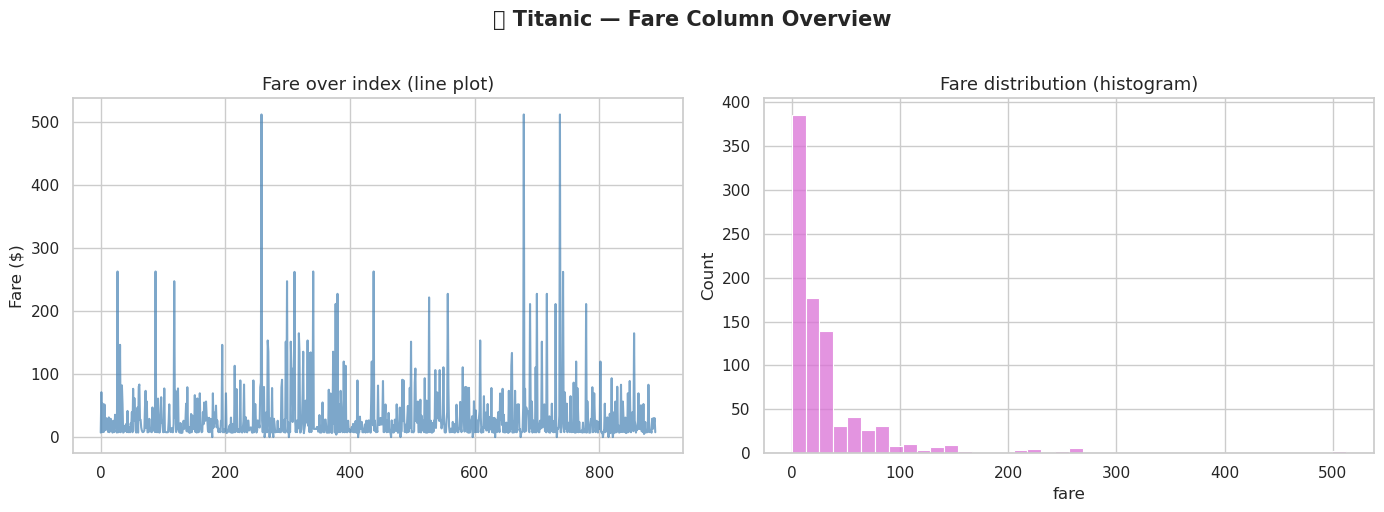

In [72]:
# ─────────────────────────────────────────────────────
# 📈 Quick look at the data distribution
# ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["fare"].plot(ax=axes[0], color="steelblue", alpha=0.7)
axes[0].set_title("Fare over index (line plot)", fontsize=13)
axes[0].set_ylabel("Fare ($)")

sns.histplot(df, x="fare", ax=axes[1], color="orchid", bins=40)
axes[1].set_title("Fare distribution (histogram)", fontsize=13)

plt.suptitle("🚢 Titanic — Fare Column Overview", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [73]:
# ─────────────────────────────────────────────────────
# 📊 Summary statistics
# ─────────────────────────────────────────────────────
df.describe().style.background_gradient(cmap="Blues")

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<div style="border: 1px solid #fadbd8; border-left: 6px solid #e74c3c; padding: 25px 28px; border-radius: 4px; margin: 20px 0;">

# 📐 Part 1: RANGE

## 🤔 What is Range?

> **Range = Maximum Value − Minimum Value**

It's the **simplest** measure of spread.

### 🏙️ Real-Life Analogy:
Imagine measuring **temperatures in a city for a year**:
- Hottest day: 45°C
- Coldest day: 5°C
- **Range = 45 − 5 = 40°C** → The city experiences a wide temperature variation!

### ✅ When to Use:
- Quick overview of how wide your data is
- Works well for small, clean datasets

### ❌ When NOT to Use:
- When you have **outliers** (extreme values) — Range is very sensitive to them!
- Example: If one person in a salary survey earns ₹1 Crore, the range shoots up unrealistically

</div>

In [74]:
# ─────────────────────────────────────────────────────
# 📐 RANGE — Step by Step
# ─────────────────────────────────────────────────────

# Step 1: Find Maximum
maximum_val = max(df["age"].dropna())

# Step 2: Find Minimum
minimum_val = min(df["age"].dropna())

# Step 3: Range = Max - Min
age_range = maximum_val - minimum_val

print(f"🔼 Maximum Age : {maximum_val}")
print(f"🔽 Minimum Age : {minimum_val}")
print(f"📐 Range       : {age_range} years")

# Shortcut using NumPy
range_numpy = np.ptp(df["age"].dropna())
print(f"\n⚡ Same result using np.ptp(): {range_numpy} years")

🔼 Maximum Age : 80.0
🔽 Minimum Age : 0.42
📐 Range       : 79.58 years

⚡ Same result using np.ptp(): 79.58 years


<div style="border: 1px solid #d6eaf8; border-left: 6px solid #2980b9; padding: 25px 28px; border-radius: 4px; margin: 20px 0;">

# 📦 Part 2: INTER-QUARTILE RANGE (IQR)

## 🤔 What is IQR?

Range is sensitive to outliers. IQR solves that problem!

> **IQR = Q3 − Q1** (the spread of the middle 50% of your data)

### 🎓 Analogy — Exam Scores:
Imagine 100 students took an exam (scores: 0 to 100):
- Sort everyone by score
- **Q1 (25th percentile)** = Score of the 25th student = 45
- **Q2 (50th percentile = Median)** = Score of the 50th student = 65
- **Q3 (75th percentile)** = Score of the 75th student = 80
- **IQR = 80 − 45 = 35**

This means the **middle half** of students scored within a 35-point range!

### 🛡️ Why IQR is better than Range:
- **Ignores extreme outliers** (top 25% and bottom 25% are cut off)
- Great for **skewed data** (like salary distributions)
- Used to **detect outliers** using the 1.5×IQR rule

### 📐 The 1.5×IQR Outlier Rule:
- **Lower Bound** = Q1 − 1.5 × IQR
- **Upper Bound** = Q3 + 1.5 × IQR
- Any value **outside** these bounds = **Outlier!**

</div>

In [75]:
# ─────────────────────────────────────────────────────
# 📦 IQR — Step by Step
# ─────────────────────────────────────────────────────

data_to_find_quartile = [5, 2, 6, 8, 15, 12, 18, 22, 20]
ds = pd.Series(data_to_find_quartile)

# Step 1: Sort the data
print("Step 1 — Sorted Data:")
print(ds.sort_values().values)

# Step 2: Find Median
median = ds.median()
print(f"\nStep 2 — Median: {median}")

# Step 3: Find Quartiles
q1 = ds.quantile(0.25, interpolation='midpoint')
q2 = ds.quantile(0.50, interpolation='midpoint')
q3 = ds.quantile(0.75, interpolation='midpoint')

print(f"\nStep 3 — Quartiles:")
print(f"  Q1 (25th percentile): {q1}")
print(f"  Q2 (50th percentile / Median): {q2}")
print(f"  Q3 (75th percentile): {q3}")

# Step 4: Calculate IQR
iqr = q3 - q1
print(f"\nStep 4 — IQR (Q3 - Q1): {iqr}")

# Step 5: Find bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"\nStep 5 — Outlier Bounds:")
print(f"  Lower Bound: {lower_bound}")
print(f"  Upper Bound: {upper_bound}")

# Step 6: Find Outliers
outliers = ds[(ds < lower_bound) | (ds > upper_bound)]
print(f"\nStep 6 — Outliers: {outliers.values if len(outliers) > 0 else 'None'}")

Step 1 — Sorted Data:
[ 2  5  6  8 12 15 18 20 22]

Step 2 — Median: 12.0

Step 3 — Quartiles:
  Q1 (25th percentile): 6.0
  Q2 (50th percentile / Median): 12.0
  Q3 (75th percentile): 18.0

Step 4 — IQR (Q3 - Q1): 12.0

Step 5 — Outlier Bounds:
  Lower Bound: -12.0
  Upper Bound: 36.0

Step 6 — Outliers: None


/tmp/ipykernel_11416/560403616.py:24: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


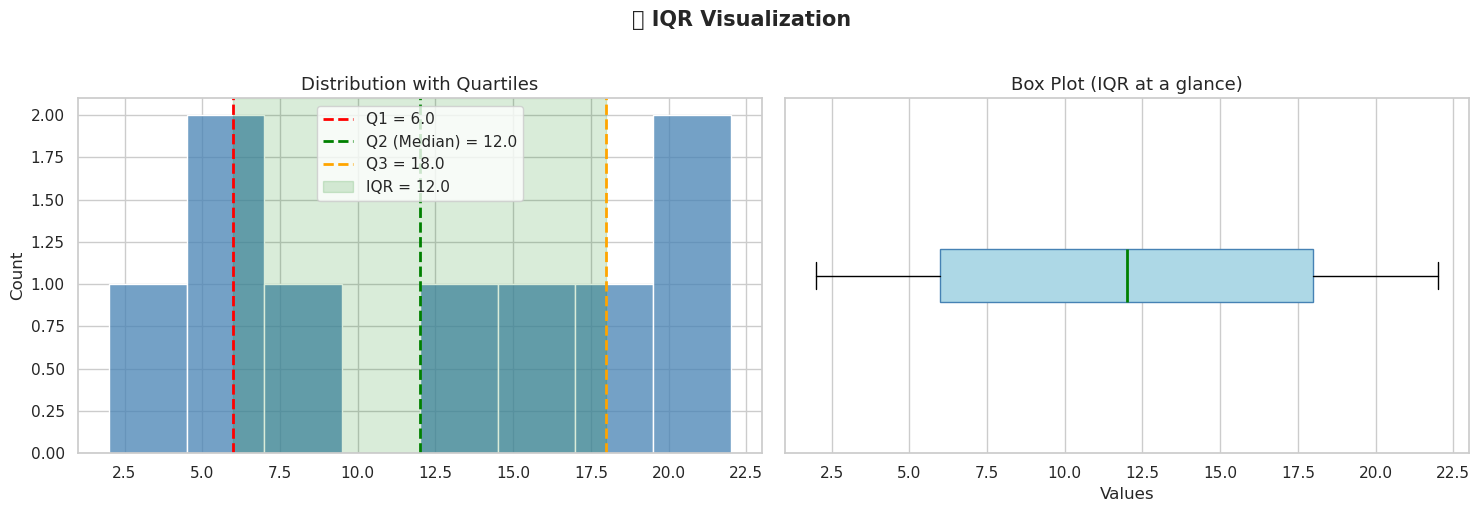


💡 The box in a Box Plot literally IS the IQR (from Q1 to Q3)!
   The line in the middle is the Median (Q2)
   The whiskers extend to 1.5 × IQR
   Dots beyond whiskers = OUTLIERS


In [77]:
# ─────────────────────────────────────────────────────
# 🎨 Visual: Distribution with Quartile Lines
# ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram with quartile lines
sns.histplot(ds, ax=axes[0], color="steelblue", bins=8)
axes[0].axvline(q1, color='red',    linestyle='--', linewidth=2, label=f'Q1 = {q1}')
axes[0].axvline(q2, color='green',  linestyle='--', linewidth=2, label=f'Q2 (Median) = {q2}')
axes[0].axvline(q3, color='orange', linestyle='--', linewidth=2, label=f'Q3 = {q3}')
axes[0].axvspan(q1, q3, alpha=0.15, color='green', label=f'IQR = {iqr}')
axes[0].legend()
axes[0].set_title("Distribution with Quartiles", fontsize=13)

# Box plot — perfect IQR visualization!
axes[1].boxplot(ds, vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='steelblue'),
               medianprops=dict(color='green', linewidth=2))
axes[1].set_title("Box Plot (IQR at a glance)", fontsize=13)
axes[1].set_xlabel("Values")
axes[1].set_yticks([])

plt.suptitle("📦 IQR Visualization", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 The box in a Box Plot literally IS the IQR (from Q1 to Q3)!")
print("   The line in the middle is the Median (Q2)")
print("   The whiskers extend to 1.5 × IQR")
print("   Dots beyond whiskers = OUTLIERS")

<div style="border: 1px solid #d5f5e3; border-left: 6px solid #27ae60; padding: 25px 28px; border-radius: 4px; margin: 20px 0;">

# 📉 Part 3: VARIANCE

## 🤔 What is Variance?

> Variance tells you: **"On average, how far away is each data point from the mean?"** (but squared)

### 🎯 Analogy — Arrow & Target:
Imagine you're shooting arrows at a bullseye:
- If all arrows hit the center → **Low Variance** ✅
- If arrows are scattered all over → **High Variance** ❌

### 📐 Formula:

**Population Variance:**
$$\sigma^2 = \frac{\sum(x_i - \bar{x})^2}{N}$$

**Sample Variance (use this for data samples):**
$$s^2 = \frac{\sum(x_i - \bar{x})^2}{n-1}$$

### ❓ Why Do We Square It?
- Without squaring: `(5-7) + (9-7) = -2 + 2 = 0` → cancels out!
- With squaring: `(-2)² + (2)² = 4 + 4 = 8` → measures actual spread!

### ❓ Why Divide by (n-1) for Samples?
- This is called **Bessel's Correction** or **Degrees of Freedom**
- Using `n-1` makes our estimate of variance **less biased** (more accurate)
- If we only divide by `n`, we slightly **underestimate** the true population variance

### ✅ When to Use:
- When you need to understand the **spread of data mathematically**
- Building block for **Standard Deviation** and many ML algorithms
- Used in statistical tests (ANOVA, F-test, etc.)

### ❌ Downside:
- Units are **squared** (if data is in meters, variance is in meters²) — hard to interpret!
- That's why we usually use Standard Deviation instead

</div>

In [78]:
# ─────────────────────────────────────────────────────
# 📉 VARIANCE — Step by Step
# ─────────────────────────────────────────────────────

df_v = np.array([2, 3, 4, 5, 6])

# Step 1: Calculate Mean
mean = np.mean(df_v)

# Step 2: Subtract mean from each value
deviations = df_v - mean

# Step 3: Square the deviations
squared_devs = deviations ** 2

# Step 4: Calculate variance (ddof=1 means divide by n-1)
var_manual = np.sum(squared_devs) / (len(df_v) - 1)
var_numpy  = np.var(df_v, ddof=1)   # ddof=1 → sample variance

print(f"Data: {df_v}")
print(f"Mean: {mean}")
print(f"\nDeviations from mean: {deviations}")
print(f"Squared deviations:   {squared_devs}")
print(f"Sum of squared devs:  {np.sum(squared_devs)}")
print(f"\nVariance (manual):    {var_manual}")
print(f"Variance (np.var):    {var_numpy}")

Data: [2 3 4 5 6]
Mean: 4.0

Deviations from mean: [-2. -1.  0.  1.  2.]
Squared deviations:   [4. 1. 0. 1. 4.]
Sum of squared devs:  10.0

Variance (manual):    2.5
Variance (np.var):    2.5


/tmp/ipykernel_11416/308744462.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


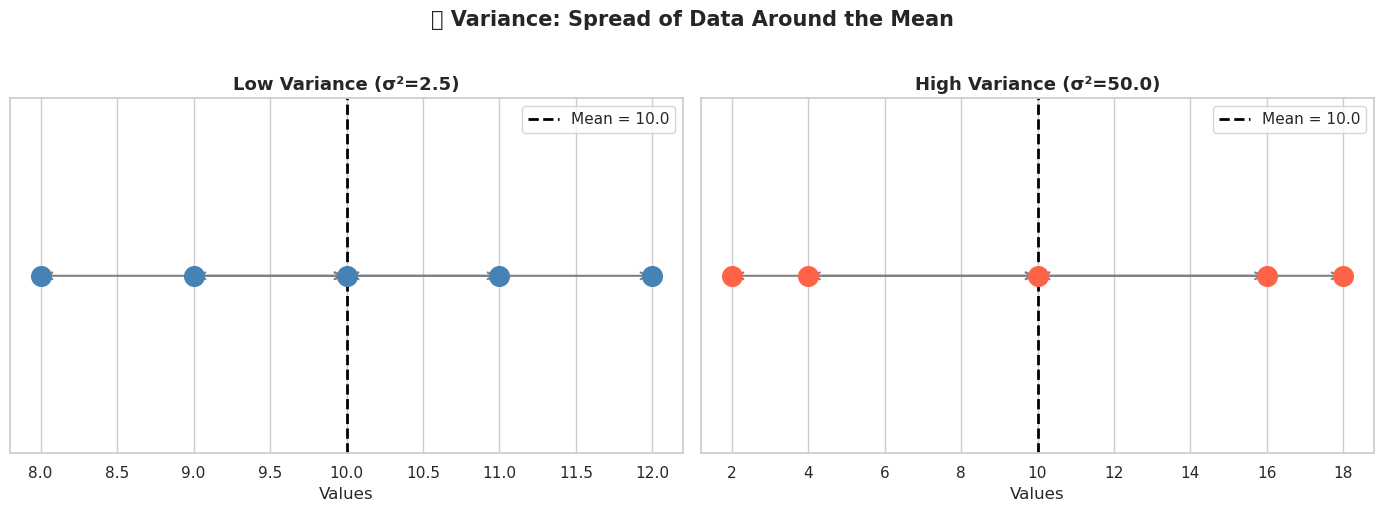

In [79]:
# ─────────────────────────────────────────────────────
# 🎨 Visual: Low vs High Variance Comparison
# ─────────────────────────────────────────────────────
low_var  = np.array([8, 9, 10, 11, 12])    # Tightly clustered
high_var = np.array([2, 4, 10, 16, 18])    # Widely spread

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in zip(
    axes,
    [low_var, high_var],
    [f"Low Variance (σ²={np.var(low_var, ddof=1):.1f})",
     f"High Variance (σ²={np.var(high_var, ddof=1):.1f})"],
    ["steelblue", "tomato"]
):
    mean_val = np.mean(data)
    ax.scatter(data, [1]*len(data), color=color, s=200, zorder=5)
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=2, label=f'Mean = {mean_val}')
    for val in data:
        ax.annotate('', xy=(mean_val, 1), xytext=(val, 1),
                   arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0.8, 1.2)
    ax.set_yticks([])
    ax.legend()
    ax.set_xlabel("Values")

plt.suptitle("📉 Variance: Spread of Data Around the Mean", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<div style="border: 1px solid #fdebd0; border-left: 6px solid #e67e22; padding: 25px 28px; border-radius: 4px; margin: 20px 0;">

# 📏 Part 4: STANDARD DEVIATION vs MEAN DEVIATION

## 🤔 Standard Deviation (SD)

> **Standard Deviation = √Variance**

It tells you: **"On average, how far are the values from the mean?"** — in the **same units** as the data!

### 🌡️ Analogy:
If your test scores are: 60, 70, 80, 90, 100:
- Mean = 80
- SD = 15.8 (roughly speaking, most scores are within 15.8 points of 80)

---

## 🔍 Standard Deviation VS Mean Deviation (Normal Deviation)

| Feature | Mean Deviation (MAD) | Standard Deviation (SD) |
|---|---|---|
| **Full Name** | Mean Absolute Deviation | Standard Deviation |
| **Formula** | `Σ|xᵢ - mean| / n` | `√(Σ(xᵢ - mean)² / n-1)` |
| **Uses Squaring?** | ❌ No — uses absolute value | ✅ Yes — squares deviations |
| **Outlier Sensitivity** | Less sensitive | More sensitive |
| **Units** | Same as data | Same as data |
| **Common Use** | Simpler, more intuitive | Industry standard in stats/ML |
| **Example (data: 1,3,5)** | MAD = 1.33 | SD ≈ 2.0 |

### 🥊 When to Use Which?
- **MAD** → When your data has **lots of outliers** (e.g., income data)
- **SD** → Almost always! It's the industry standard because it connects to **normal distributions** and **probability theory**

### 🧠 Key Property — The 68-95-99.7 Rule (SD):
In a **normal distribution**:
- **1 SD** from mean covers **~68%** of data
- **2 SD** from mean covers **~95%** of data  
- **3 SD** from mean covers **~99.7%** of data

</div>

In [80]:
# ─────────────────────────────────────────────────────
# 📏 Standard Deviation vs Mean Deviation — Side by Side
# ─────────────────────────────────────────────────────

df_v = np.array([2, 3, 4, 5, 6])

mean_val = np.mean(df_v)

# Mean Deviation (MAD)
mad = np.mean(np.abs(df_v - mean_val))

# Standard Deviation
std = np.std(df_v, ddof=1)       # ddof=1 → sample SD
var = np.var(df_v, ddof=1)       # SD = sqrt(Variance)

print(f"Data: {df_v}")
print(f"Mean: {mean_val}")
print()
print(f"{'Metric':<30} {'Formula':<35} {'Value'}")
print("-" * 75)
print(f"{'Mean Deviation (MAD)':<30} {'Σ|xᵢ - mean| / n':<35} {mad:.4f}")
print(f"{'Variance':<30} {'Σ(xᵢ - mean)² / (n-1)':<35} {var:.4f}")
print(f"{'Standard Deviation (SD)':<30} {'√Variance':<35} {std:.4f}")
print()
print("💡 Relationship: SD = √Variance")
print(f"   Proof: √{var:.4f} = {np.sqrt(var):.4f} ✅")

Data: [2 3 4 5 6]
Mean: 4.0

Metric                         Formula                             Value
---------------------------------------------------------------------------
Mean Deviation (MAD)           Σ|xᵢ - mean| / n                    1.2000
Variance                       Σ(xᵢ - mean)² / (n-1)               2.5000
Standard Deviation (SD)        √Variance                           1.5811

💡 Relationship: SD = √Variance
   Proof: √2.5000 = 1.5811 ✅


/tmp/ipykernel_11416/1731798892.py:29: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


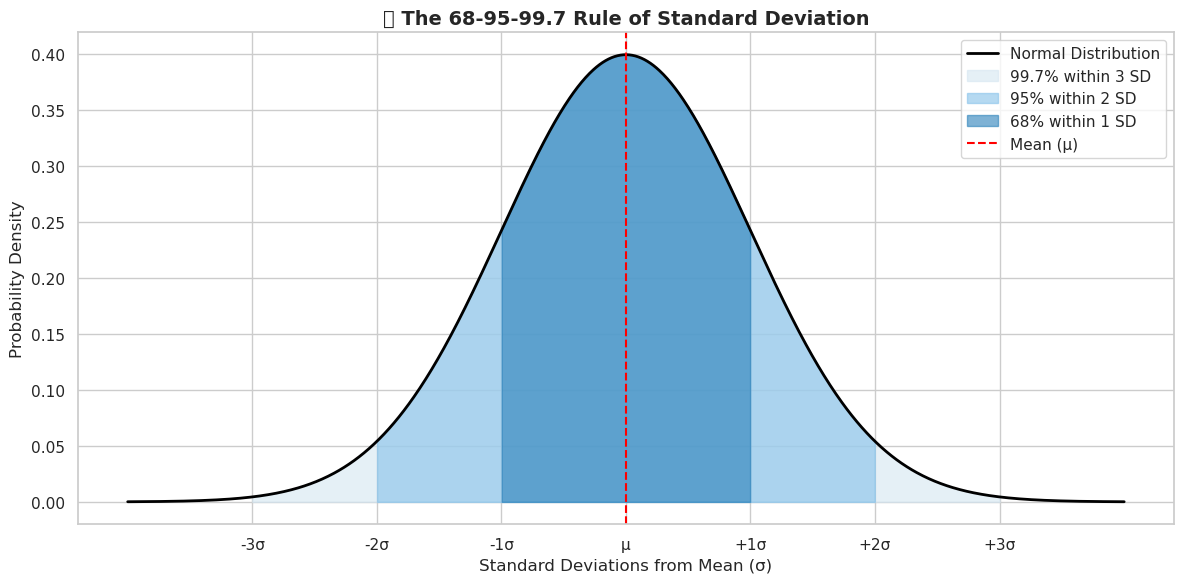

In [81]:
# ─────────────────────────────────────────────────────
# 🎨 Visual: 68-95-99.7 Rule
# ─────────────────────────────────────────────────────
x = np.linspace(-4, 4, 1000)
y = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, y, 'black', linewidth=2, label='Normal Distribution')

fills = [
    (-3, 3, '#d4e6f1', '99.7% within 3 SD'),
    (-2, 2, '#85c1e9', '95% within 2 SD'),
    (-1, 1, '#2980b9', '68% within 1 SD'),
]

for x1, x2, color, label in fills:
    mask = (x >= x1) & (x <= x2)
    ax.fill_between(x[mask], y[mask], alpha=0.6, color=color, label=label)

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean (μ)')
ax.set_title("📏 The 68-95-99.7 Rule of Standard Deviation", fontsize=14, fontweight='bold')
ax.set_xlabel("Standard Deviations from Mean (σ)")
ax.set_ylabel("Probability Density")
ax.legend(loc='upper right')
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_xticklabels(['-3σ', '-2σ', '-1σ', 'μ', '+1σ', '+2σ', '+3σ'])

plt.tight_layout()
plt.show()

<div style="border: 1px solid #e8daef; border-left: 6px solid #8e44ad; padding: 25px 28px; border-radius: 4px; margin: 20px 0;">

# 🎯 Part 5: STANDARD ERROR (SE)

## 🤔 What is Standard Error?

> **SE = SD / √n**

Standard Error tells you: **"How accurate is our estimated mean?"**

### 🗳️ Analogy — Opinion Poll:
You want to know: *"What % of Pakistan's population likes cricket?"*
- You can't ask all 220 million people!
- So you ask a **sample** of 1,000 people
- Your sample says: **75% like cricket**
- But is that the exact truth? Maybe the real answer is 73% or 77%...
- **SE tells you how close your sample mean is to the true population mean!**

### 📐 Key Insight:
- Bigger sample (n ↑) → SE gets **smaller** → Mean estimate is **more accurate**
- Smaller sample (n ↓) → SE gets **bigger** → Mean estimate is **less accurate**

### 🔑 SD vs SE — Don't Confuse Them!
| | Standard Deviation (SD) | Standard Error (SE) |
|---|---|---|
| **Measures** | Spread of individual data points | Accuracy of your estimated mean |
| **Affected by sample size?** | Not much | Yes! SE = SD/√n |
| **Use when...** | Describing your dataset | Estimating population mean |

### ✅ When to Use SE:
- When reporting survey results
- Scientific papers (error bars on graphs = SE)
- Hypothesis testing and confidence intervals

</div>

In [82]:
# ─────────────────────────────────────────────────────
# 🎯 Standard Error — Calculation & Intuition
# ─────────────────────────────────────────────────────

df_v = np.array([2, 3, 4, 5, 6])
std = np.std(df_v, ddof=1)

# Standard Error formula: SE = SD / √n
n  = len(df_v)
se = std / np.sqrt(n)

print(f"Data: {df_v}")
print(f"Sample Size (n): {n}")
print(f"Standard Deviation (SD): {std:.4f}")
print(f"Standard Error (SE) = SD / √n = {std:.4f} / √{n} = {se:.4f}")
print()

# Show how SE decreases as sample size grows
print("📉 SE decreases as sample size increases:")
print(f"{'Sample Size':<15} {'SE':<10}")
print("-" * 25)
for sample_n in [5, 10, 50, 100, 1000]:
    se_n = std / np.sqrt(sample_n)
    print(f"n = {sample_n:<11} SE = {se_n:.4f}")

Data: [2 3 4 5 6]
Sample Size (n): 5
Standard Deviation (SD): 1.5811
Standard Error (SE) = SD / √n = 1.5811 / √5 = 0.7071

📉 SE decreases as sample size increases:
Sample Size     SE        
-------------------------
n = 5           SE = 0.7071
n = 10          SE = 0.5000
n = 50          SE = 0.2236
n = 100         SE = 0.1581
n = 1000        SE = 0.0500


/tmp/ipykernel_11416/1456193014.py:19: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


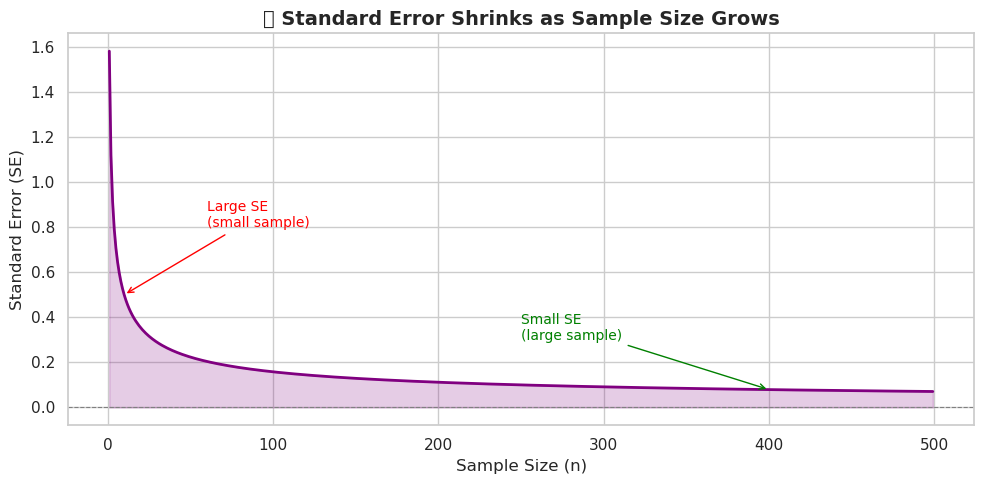

In [83]:
# ─────────────────────────────────────────────────────
# 🎨 Visual: How SE shrinks with larger sample size
# ─────────────────────────────────────────────────────

sample_sizes = np.arange(1, 500)
se_values = std / np.sqrt(sample_sizes)

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, se_values, color='purple', linewidth=2)
plt.fill_between(sample_sizes, se_values, alpha=0.2, color='purple')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Sample Size (n)", fontsize=12)
plt.ylabel("Standard Error (SE)", fontsize=12)
plt.title("🎯 Standard Error Shrinks as Sample Size Grows", fontsize=14, fontweight='bold')
plt.annotate("Large SE\n(small sample)", xy=(10, se_values[9]), fontsize=10, color='red',
             xytext=(60, 0.8), arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate("Small SE\n(large sample)", xy=(400, se_values[399]), fontsize=10, color='green',
             xytext=(250, 0.3), arrowprops=dict(arrowstyle='->', color='green'))
plt.tight_layout()
plt.show()

<div style="border: 1px solid #fef3cd; border-left: 6px solid #d4ac0d; padding: 25px 28px; border-radius: 4px; margin: 20px 0;">

# 🔔 Part 6: DATA DISTRIBUTION AND ITS TYPES

## 🤔 What is Data Distribution?

> A distribution describes **how data is spread out** across values — where are most values? Where are few?

### 🗺️ Think of it like a population map:
- Most people live in cities (tall bars in histogram)
- Few people in deserts (short bars)
- The "map" of where people are = the distribution!

---

## 📊 Types of Distribution

### 1️⃣ Normal Distribution (Bell Curve) 🔔
- **Shape:** Symmetric bell shape
- **Example:** Heights of adults, IQ scores, measurement errors
- **Rule:** Mean = Median = Mode (all in the center!)
- **Skew:** 0 (perfectly balanced)

### 2️⃣ Right-Skewed Distribution (Positive Skew) ➡️
- **Shape:** Long tail on the RIGHT
- **Example:** Incomes, housing prices, social media followers
- **Rule:** Mean > Median > Mode (pulled right by outliers)
- Most people earn low, a few earn extremely high → pulls mean right

### 3️⃣ Left-Skewed Distribution (Negative Skew) ⬅️
- **Shape:** Long tail on the LEFT
- **Example:** Age at death (most die old), exam scores after easy test
- **Rule:** Mean < Median < Mode (pulled left by outliers)

### 4️⃣ Uniform Distribution 📦
- **Shape:** Flat — all values equally likely
- **Example:** Rolling a fair dice (1-6 equally likely)

### 5️⃣ Bimodal Distribution 🐪
- **Shape:** Two peaks (like a camel's humps)
- **Example:** Test scores of two very different groups mixed together

### 6️⃣ Exponential Distribution 📉
- **Shape:** Starts high, drops sharply
- **Example:** Time between customer arrivals, radioactive decay

---

### 🔑 Why Does Distribution Type Matter?
- Choosing the wrong statistical test → wrong conclusions!
- Normal distribution → use mean & SD
- Skewed distribution → use median & IQR instead!
- Machine learning models often assume normal distribution

</div>

/tmp/ipykernel_11416/4240455505.py:37: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11416/4240455505.py:37: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


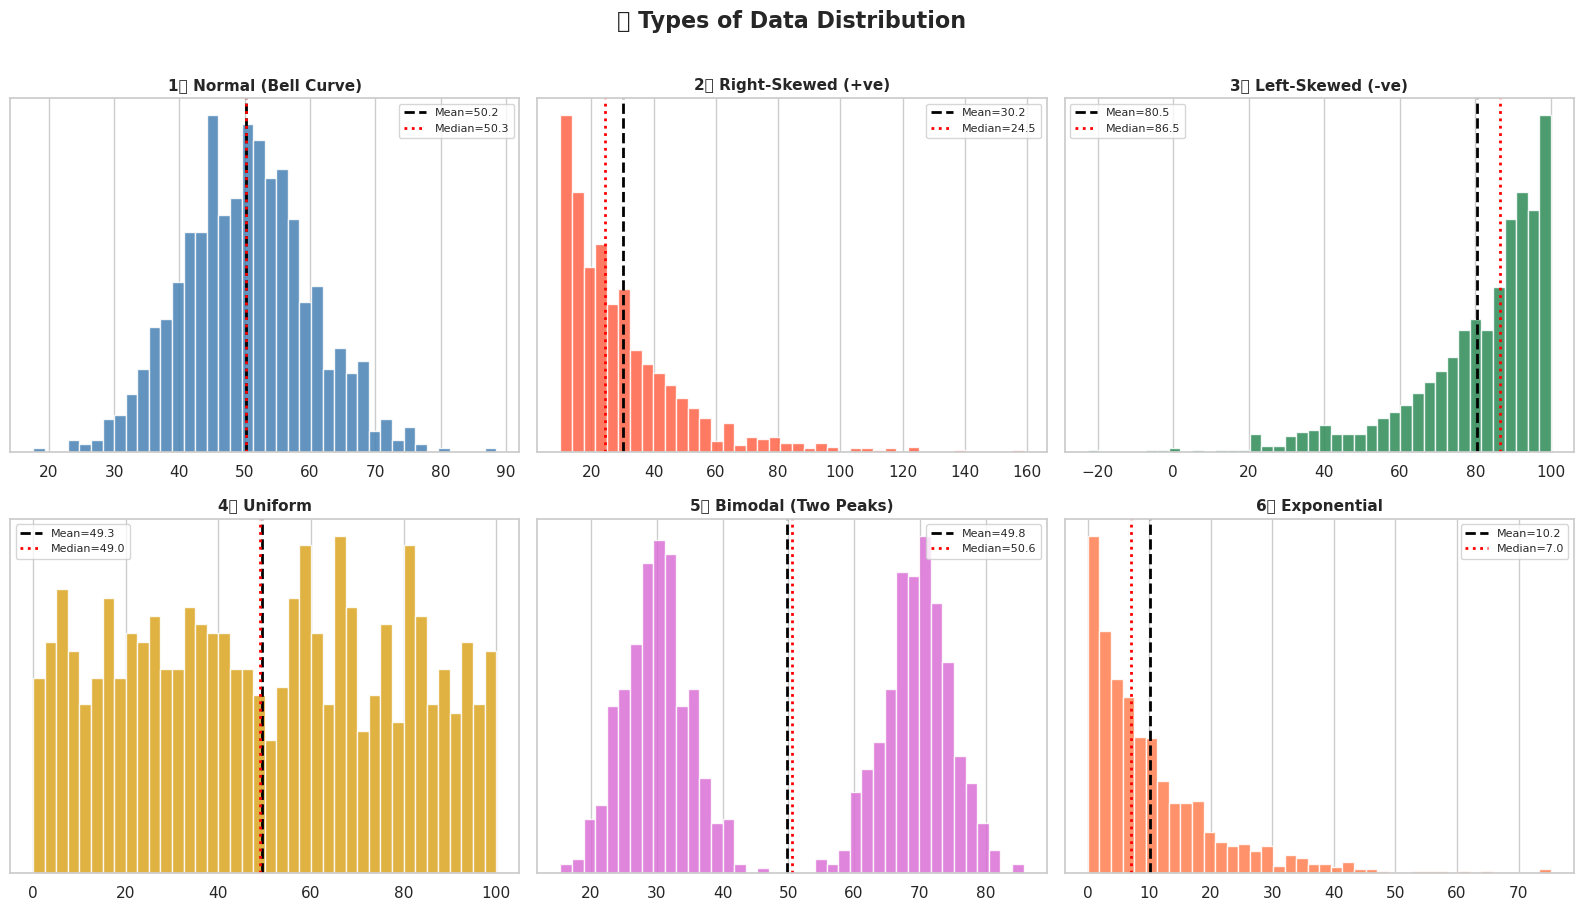


💡 Notice how Mean (black dashed) and Median (red dotted) are:
   - Same position in Normal distribution ✅
   - Mean pulled RIGHT in Right-Skewed data (outliers on right)
   - Mean pulled LEFT in Left-Skewed data (outliers on left)


In [84]:
# ─────────────────────────────────────────────────────
# 🔔 Visualizing All Distribution Types
# ─────────────────────────────────────────────────────
np.random.seed(42)

normal      = np.random.normal(loc=50, scale=10, size=1000)
right_skew  = np.random.exponential(scale=20, size=1000) + 10
left_skew   = 100 - np.random.exponential(scale=20, size=1000)
uniform     = np.random.uniform(0, 100, size=1000)
bimodal     = np.concatenate([
    np.random.normal(30, 5, 500),
    np.random.normal(70, 5, 500)
])
exponential = np.random.exponential(scale=10, size=1000)

datasets = [
    (normal,      "1️⃣ Normal (Bell Curve)",        "steelblue"),
    (right_skew,  "2️⃣ Right-Skewed (+ve)",          "tomato"),
    (left_skew,   "3️⃣ Left-Skewed (-ve)",           "seagreen"),
    (uniform,     "4️⃣ Uniform",                    "goldenrod"),
    (bimodal,     "5️⃣ Bimodal (Two Peaks)",         "orchid"),
    (exponential, "6️⃣ Exponential",                 "coral"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (data, title, color) in zip(axes, datasets):
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(data), color='black', linestyle='--', linewidth=2, label=f'Mean={np.mean(data):.1f}')
    ax.axvline(np.median(data), color='red',   linestyle=':',  linewidth=2, label=f'Median={np.median(data):.1f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_yticks([])

plt.suptitle("🔔 Types of Data Distribution", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Notice how Mean (black dashed) and Median (red dotted) are:")
print("   - Same position in Normal distribution ✅")
print("   - Mean pulled RIGHT in Right-Skewed data (outliers on right)")
print("   - Mean pulled LEFT in Left-Skewed data (outliers on left)")

/tmp/ipykernel_11416/3897170619.py:21: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


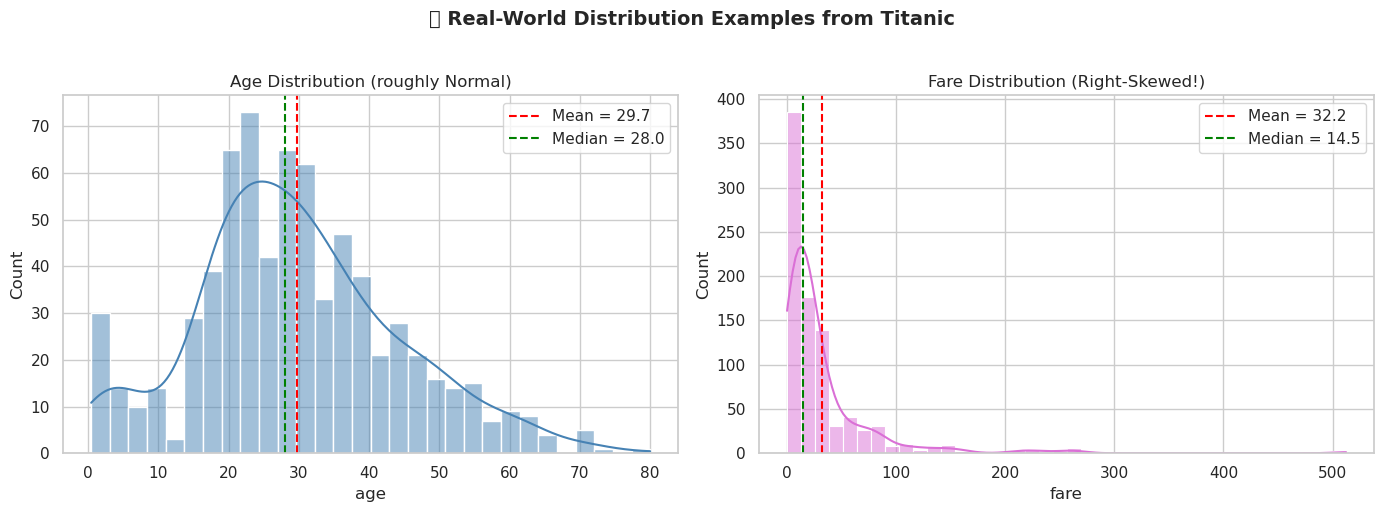


Fare: Mean=32.20, Median=14.45
📌 Since Mean >> Median → Fare is RIGHT-SKEWED
   A few very rich passengers paid extremely high fares, pulling the mean up!


In [85]:
# ─────────────────────────────────────────────────────
# 🚢 Real Data: Titanic Fare Distribution
# ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
sns.histplot(df['age'].dropna(), ax=axes[0], bins=30, color='steelblue', kde=True)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean = {df['age'].mean():.1f}")
axes[0].axvline(df['age'].median(), color='green', linestyle='--', label=f"Median = {df['age'].median():.1f}")
axes[0].set_title("Age Distribution (roughly Normal)", fontsize=12)
axes[0].legend()

# Fare distribution (right-skewed)
sns.histplot(df['fare'], ax=axes[1], bins=40, color='orchid', kde=True)
axes[1].axvline(df['fare'].mean(), color='red', linestyle='--', label=f"Mean = {df['fare'].mean():.1f}")
axes[1].axvline(df['fare'].median(), color='green', linestyle='--', label=f"Median = {df['fare'].median():.1f}")
axes[1].set_title("Fare Distribution (Right-Skewed!)", fontsize=12)
axes[1].legend()

plt.suptitle("🚢 Real-World Distribution Examples from Titanic", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFare: Mean={df['fare'].mean():.2f}, Median={df['fare'].median():.2f}")
print("📌 Since Mean >> Median → Fare is RIGHT-SKEWED")
print("   A few very rich passengers paid extremely high fares, pulling the mean up!")

<div style="border: 1px solid #d5d8dc; border-left: 6px solid #2c3e50; padding: 25px 28px; border-radius: 4px; margin: 20px 0;">

# 🧮 Part 7: ALL MEASURES TOGETHER — Quick Reference

## 📋 Summary Table

| Measure | Formula | Best For | Avoid When |
|---|---|---|---|
| **Range** | Max − Min | Quick overview | Outliers present |
| **IQR** | Q3 − Q1 | Skewed data, outlier detection | Need full spread |
| **Variance** | Σ(xᵢ−mean)² / (n-1) | Math formulas, ML | Interpreting units |
| **SD** | √Variance | Most situations! | Very skewed data |
| **SE** | SD / √n | Estimating accuracy of mean | Describing data itself |

## 🏆 Golden Rules:
1. **Normal distribution** → Use Mean + SD
2. **Skewed distribution** → Use Median + IQR
3. **Reporting research/surveys** → Report SE alongside Mean
4. **Detecting outliers** → Use IQR rule (1.5 × IQR)

</div>

In [86]:
# ─────────────────────────────────────────────────────
# 🧮 All measures computed together on Titanic Age data
# ─────────────────────────────────────────────────────
ages = df['age'].dropna()

q1  = ages.quantile(0.25)
q3  = ages.quantile(0.75)
iqr = q3 - q1
std = np.std(ages, ddof=1)
se  = std / np.sqrt(len(ages))

print("🚢 Titanic — AGE Column Statistics")
print("=" * 40)
print(f"Count            : {len(ages)}")
print(f"Mean             : {ages.mean():.2f} years")
print(f"Median           : {ages.median():.2f} years")
print()
print(f"Range            : {np.ptp(ages):.2f} years  (Max-Min = {ages.max():.1f}-{ages.min():.1f})")
print(f"IQR              : {iqr:.2f} years  (Q1={q1:.1f}, Q3={q3:.1f})")
print(f"Variance         : {np.var(ages, ddof=1):.2f} years²")
print(f"Std Deviation    : {std:.2f} years")
print(f"Standard Error   : {se:.2f} years")
print()
print(f"📊 Interpretation:")
print(f"   Average passenger was {ages.mean():.1f} years old, ±{std:.1f} years (SD)")
print(f"   Middle 50% of passengers were {q1:.1f} to {q3:.1f} years old")
print(f"   Our mean estimate is accurate to ±{se:.2f} years (SE)")

🚢 Titanic — AGE Column Statistics
Count            : 714
Mean             : 29.70 years
Median           : 28.00 years

Range            : 79.58 years  (Max-Min = 80.0-0.4)
IQR              : 17.88 years  (Q1=20.1, Q3=38.0)
Variance         : 211.02 years²
Std Deviation    : 14.53 years
Standard Error   : 0.54 years

📊 Interpretation:
   Average passenger was 29.7 years old, ±14.5 years (SD)
   Middle 50% of passengers were 20.1 to 38.0 years old
   Our mean estimate is accurate to ±0.54 years (SE)


In [ ]:
# ─────────────────────────────────────────────────────
# 🎨 Final Summary Visualization
# ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram with SD bands
mean_age = ages.mean()
std_age  = ages.std(ddof=1)
sns.histplot(ages, ax=axes[0], bins=30, color='steelblue', kde=True, alpha=0.7)
for i, (mult, color, alpha) in enumerate([(1, 'tomato', 0.3), (2, 'orange', 0.2), (3, 'yellow', 0.1)]):
    axes[0].axvspan(mean_age - mult*std_age, mean_age + mult*std_age,
                   alpha=alpha, color=color, label=f'±{mult}σ')
axes[0].axvline(mean_age, color='red', linewidth=2, label=f'Mean={mean_age:.1f}')
axes[0].set_title("Age: SD Bands", fontsize=12)
axes[0].legend(fontsize=8)

# 2. Box plot
axes[1].boxplot(ages, vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='orange', markersize=4))
axes[1].set_title("Age: Box Plot (IQR)", fontsize=12)
axes[1].set_yticks([])
axes[1].set_xlabel("Age")

# 3. Bar chart comparing all dispersion measures
measures = {'Range': np.ptp(ages), 'IQR': iqr, 'SD': std_age, 'SE': se, 'Var/10': np.var(ages, ddof=1)/10}
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = axes[2].bar(measures.keys(), measures.values(), color=colors, edgecolor='white')
for bar, val in zip(bars, measures.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', fontsize=9)
axes[2].set_title("Comparison of Dispersion Measures", fontsize=12)
axes[2].set_ylabel("Value")

plt.suptitle("🧮 Complete Dispersion Analysis — Titanic Age", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("✅ Note: Variance divided by 10 for scale comparison only")

<div style="border: 1px solid #d1f2eb; border-left: 6px solid #1abc9c; padding: 25px 28px; border-radius: 4px; margin: 20px 0;">

# 🏁 Summary: The Full Picture

## 🎯 When you get a new dataset, follow this checklist:

1. **Plot a histogram** → Understand the distribution shape
2. **Check skewness** → Is it normal, right-skewed, or left-skewed?
3. **Choose the right central measure:**
   - Normal → Mean
   - Skewed → Median
4. **Choose the right dispersion measure:**
   - Normal → Standard Deviation
   - Skewed → IQR
5. **Check for outliers** → Use IQR × 1.5 rule or box plot
6. **If reporting a study** → Report Standard Error too!

## 📐 All Formulas at a Glance:

| Measure | Formula |
|---|---|
| Range | Max − Min |
| IQR | Q3 − Q1 |
| Lower Bound | Q1 − 1.5 × IQR |
| Upper Bound | Q3 + 1.5 × IQR |
| Variance (sample) | Σ(xᵢ − x̄)² / (n−1) |
| Std Deviation | √Variance |
| Standard Error | SD / √n |

> 🧠 **Remember:** Standard Deviation = √Variance → they're two sides of the same coin!

</div>